In [312]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [313]:
# Importing data
orders = pd.read_csv("../data/raw/orders.csv")
products = pd.read_csv("../data/raw/products.csv")

#order_lines has bad lines
bad_lines_list = []
order_lines = pd.read_csv("../data/raw/order_lines.csv", engine="python", on_bad_lines = lambda x: bad_lines_list.append(x) or None)
print(f"There are {len(bad_lines_list)} bad lines, and there will be dropped.")
order_lines = order_lines = pd.read_csv("../data/raw/order_lines.csv",on_bad_lines="skip")  

There are 452 bad lines, and there will be dropped.


* 452 bad lines from order_lines table, which have 9 columns instead of 8 are dropped.

In [314]:
print(f"The memory usage of orders table was {(orders.memory_usage().sum()/1024).round(2)} KB.")
print(f"The memory usage of products table was {(products.memory_usage().sum()/1024).round(2)} KB.")
print(f"The memory usage of order_lines table was {(order_lines.memory_usage().sum()/1024).round(2)} KB")


The memory usage of orders table was 1125.69 KB.
The memory usage of products table was 5.99 KB.
The memory usage of order_lines table was 2984.69 KB


In [315]:
# -----DATA TYPES-------------

# CHANGING FOR ORDERS
orders_type_mapping = {
    "order_id": "int32",
    "channel": "category",
    "region": "category",
    "order_total":"float32",
    "num_items": "int16"
}
orders = (
    orders.astype(orders_type_mapping)
          .assign(
              order_date = pd.to_datetime(orders['order_date'])
    )
)

print(f"The size of the new Orders table become {(orders.memory_usage().sum()/1024).round(2)} KB.")
#  CHANGING FOR PRODUCTS
products['unit_cost'] = products['unit_cost'].str.replace(",",".")
products_type_mapping = { 
    'category': "category",
    "unit_price":"float32",
    "unit_cost": "float32"
}
products = ( products.astype(products_type_mapping))
print(f"The size of new Products table become {(products.memory_usage().sum()/1024).round(2)} KB.")

#  CHANGING FOR ORDER_LINES
or_lines_type_mapping = {
    "line_id": "int32",
    "order_id": "int32",
    "product_id":"int32",
    "category": "category"
}
order_lines = order_lines.astype(or_lines_type_mapping)
print(f"The size of new order_lines table become {(order_lines.memory_usage().sum()/1024).round(2)} KB.")


The size of the new Orders table become 633.32 KB.
The size of new Products table become 3.84 KB.
The size of new order_lines table become 2098.7 KB.


* Decimal formatting of the unit_cost column are changed, from "," to ".".
* Data types are changed for simpler analysis and efficient memory usage.

In [316]:
# ----Engineered Columns------------------

# shipping promotion period from the dates that the orders are done
orders['shipping_promotion_period'] = orders['order_date'].dt.month_name()
# the conditions using lists of month names

conditions = [
    orders['shipping_promotion_period'].isin(["January", "February", "March", "April", "May", "June"]),
    orders['shipping_promotion_period'].isin(["July", "August", "September"])
]

# the labels
choices = ["before", "on_promotion"]

# Assigning new values to the columns based on conditions
orders['shipping_promotion_period'] = np.select(conditions, choices, default="Unknown")


* Shipping promotion period column is engineered for adding flexibility on analysis. 

In [317]:
# ----Duplicated Rows--------------
if (orders['order_id'].duplicated().any()):
    print(f"Ohh! There are {orders['order_id'].duplicated().sum()} duplicated rows.")
else:
    print(f"Good to go! There is no duplicated row in orders table.")
 
# ORDER_LINES 
if(order_lines['line_id'].duplicated().any()):
    print(f"Unfortunately! There are {order_lines['line_id'].duplicated().sum()} rows with the same line_id, and will be dropped.")

    # Does the duplicated order_lines belong to different products or has different quantity
    
    all_dup = order_lines[order_lines['line_id'].duplicated(keep=False)]
    all_dup.sort_values('line_id')[['order_id','product_id']]
    dup_lines_diff_pro = len(all_dup[all_dup.groupby('line_id')['product_id'].transform('nunique')>1])
    dup_lines_diff_qua = len(all_dup[all_dup.groupby('line_id')['quantity'].transform('nunique')>1])
    dup_lines_diff_tot = len(all_dup[all_dup.groupby('line_id')['line_total'].transform('nunique')>1])

    if (dup_lines_diff_pro == 0 and dup_lines_diff_qua == 0 and dup_lines_diff_tot == 0):
        print("---------------------")
        print(f"None of the duplicated line_id linked to different product or quantity.so we can easily drop the last occurred.")
        print(f"Total {order_lines['line_id'].duplicated().sum()} duplicated line_id are dropped.")
        order_lines[order_lines['line_id'].duplicated(keep=False)].sort_values(by=['line_id'])
        order_lines = order_lines.drop_duplicates(subset='line_id') # keeps the first happened order_line
        print("---------------------")

    else:
        print("RED FLAG!!!")
else: 
    print(f"Good to go! There is no duplicated row in order_lines table.")

# PRODUCTS
if(products['product_id'].duplicated().any()):
    print(f"Unfortunately! There are {products['product_id'].duplicated().sum()} rows with the same product_id, and will be dropped.")
else: 
    print(f"Good to go! There is no duplicated row in products table.")


Good to go! There is no duplicated row in orders table.
Unfortunately! There are 220 rows with the same line_id, and will be dropped.
---------------------
None of the duplicated line_id linked to different product or quantity.so we can easily drop the last occurred.
Total 220 duplicated line_id are dropped.
---------------------
Good to go! There is no duplicated row in products table.


* After `checking` the duplicated line_id doesn't `are not linked` to different product or have different quantity 
* `220` duplicated rows in `order_lines` table with the same `line_id` were dropped.

In [318]:
# ------Missing Values---------------
# ORDERS TABLE
# Based on the information from the business, shipping cost from Jan - June was always €5.95.
# but between starting from July the shipping cost was free for orders more than €50.


# defining the conditions only for rows where shipping cost is missing
is_missing = orders['shipping_cost'].isna()

condition_jan_june = is_missing & (orders['shipping_promotion_period'] == "before")
condition_july_free = is_missing & (orders['shipping_promotion_period'] == "on_promotion") & (orders['order_total'] > 50)
condition_july_paid = is_missing & (orders['shipping_promotion_period'] == "on_promotion") & (orders['order_total'] <= 50)

# Group conditions and their corresponding values
conditions = [condition_jan_june, condition_july_free, condition_july_paid]
choices = [5.95, 0.00, 5.95]

# ----Engineered Column------------------
orders['shipping_cost'] = np.select(conditions, choices, default=orders['shipping_cost'])

print(f"There is {orders['shipping_cost'].isna().sum()} missing values in orders table.")
print(f"There is {products.isna().any().sum()} missing values from products table.")
print(f"There is {order_lines.isna().any().sum()} columns with missing values from order_lines table.")


There is 0 missing values in orders table.
There is 0 missing values from products table.
There is 2 columns with missing values from order_lines table.


* Based on the information from the assignment.md, missed shipping values are filled.
* And for there are missing values on the `unit_price` and `order_lines` 
    that will be fixed my `merging` `orders` table and `order_lines` table.
---
* unit_price can be filled first merged two tables orders and order_lines.
* ordertotal-line_total

In [319]:
print(f"{order_lines.isna().sum()}")

line_id           0
order_id          0
product_id        0
product_name      0
category          0
quantity          0
unit_price      927
line_total      927
dtype: int64


---

## Merging the tables

In [320]:
# JOining the tables for extra analysis information
# Merging order table and order_lines under the common order_id, to fill the missed value of unit_cost in order_lines.

merged = orders.merge(order_lines,how='inner', on='order_id')
print(f"Order and Order_lines are successfully merged on order_id.")


Order and Order_lines are successfully merged on order_id.


---

In [321]:
# first fill the missing values with 0 to make the calculation possible
# generate tempo parallel column of line_total 
merged['line_total_filled'] = merged['line_total'].fillna(0)

# generate tempo column of sum of total known price of the items 
merged['total_known_items'] = merged.groupby('order_id')['line_total_filled'].transform(sum).round(2)

# Order total is equal to line total which is summation of each items price * quantity
calculated_line_total = merged['order_total'] - merged['total_known_items'] 
merged['unit_price'] = merged['unit_price'].fillna(calculated_line_total/merged['quantity']).round(2)
merged['line_total'] = merged['unit_price'] * merged['quantity']
# dropping the temporary columns
merged = merged.drop(columns=["line_total_filled", "total_known_items"])

if (merged.isna().any().any()):
    print(f"The is {merged.isna().sum()} missing values in the merged tables.")
else:
    print("Good to go! There is no missing values in the order and order_lines table.")

Good to go! There is no missing values in the order and order_lines table.


* First order table and order_lines table merged.
* Order_total is summation of line_total which is summation each items unit_price * their quantity.
* The missed unit_price of the items is calculated from the above relation.

---

# Merging all tables and save the cleaned table

In [322]:
# Merging the merged table from(order and order_lines ) ane product table on the product id to calculate the profit margin. 

mr = merged.merge(products,how='inner', suffixes=("_mr","_pr"), on='product_id')
mr['profit_margin'] = ((mr['unit_price_mr'] - mr['unit_cost'])*mr['quantity']).round(2)
print(f"merged table and products are successfully merged on product id.")

#Dropping similar columns and saving the final cleaned csv file. 
mr = mr.drop(columns=["category_pr","unit_price_pr","product_name_pr"])
mr.to_csv("../data/processed/cleaned_merged_all.csv")
print("--------------")
print("Cleaned and merged of all tables called cleaned_merged_all is saved to the processed data.")

merged table and products are successfully merged on product id.
--------------
Cleaned and merged of all tables called cleaned_merged_all is saved to the processed data.


----
# ----EDA-----

In [323]:

# Grouping and analyzing the volume of the orders made in different promotion period.
on_promotion = mr[mr['shipping_promotion_period'] == "on_promotion"]
before_promotion = mr[mr['shipping_promotion_period'] == "before"]

orders_unique = mr.drop_duplicates('order_id') # All orders with unique orderID

# picking the unique orders
volume_pcg = ((on_promotion['order_id'].nunique())/(before_promotion['order_id'].nunique()))*100

print(f"In the promotion period, {volume_pcg: .2f}% of the orders from the before period has made.")

orders_unique.groupby('shipping_promotion_period').size().reset_index(name="unique_orders")


In the promotion period,  59.43% of the orders from the before period has made.


,shipping_promotion_period,unique_orders
0,before,11275
1,on_promotion,6701


* After the promotion the volume of the customers boomed.
* 59.43% of the volume orders from the Before-promotion period has made only in those 3-months of promotion period. 

### * Total order after and before the promotion

In [324]:
rev_pcg = ( ((on_promotion.drop_duplicates('order_id')['order_total'].sum()) /
            (before_promotion.drop_duplicates('order_id')['order_total'].sum())) *100
        ).round(2)

print(f"The promotion period generated {rev_pcg: .2f}% of the revenue from the before period.")

(orders_unique
    .groupby('shipping_promotion_period')['order_total'].agg(["sum","min","max","mean"]))


The promotion period generated  69.67% of the revenue from the before period.


,sum,min,max,mean
shipping_promotion_period,,,,
before,2397275.75,7.86,1502.439941,212.618698
on_promotion,1670105.25,7.86,1700.030029,249.232239


* The total revenue has boomed in the promotion period.
* The average of `order_total` on the promotion period increased from the previous period.
* 69.67% of the revenue from the last 6 month period was able to be reached in the promotion period.

## * does The promotion helped people to spend more?

In [325]:
# different spending tiers categorize each spending 
bins = [7.86,50,100,273,360,1000, np.inf]

labels = ["low","threshold","high","very_high","super_high","uncommon"]

# pd.cut great built in method to change continuous data to category 
mr['spending_category'] = pd.cut(mr.drop_duplicates('order_id')['order_total'],bins=bins,labels=labels)

spending_pcg = (
    pd.crosstab(mr['spending_category'], mr['shipping_promotion_period'], normalize='columns') * 100
).round(2)

print(spending_pcg)

shipping_promotion_period  before  on_promotion
spending_category                              
low                         13.38          8.18
threshold                   19.18         16.49
high                        40.26         40.89
very_high                   10.94         12.68
super_high                  15.70         20.98
uncommon                     0.54          0.78


* After the promotion the behavior of the customers has changed in some way. They like to add items to their cart to reach the threshold of 50 euro.
* Given the the comparison is 6-months period vs 3-months period the outcome is promising, and indeed it help people to spend more than 50 euro.

## * Shipping Revenue and is it covered by the revenue generated?

In [326]:
# Picking and Checking only the revenue from the orders above 50
free_promo = on_promotion[on_promotion['order_total'] > 50].copy()

total_item_revenue = free_promo['line_total'].sum()
total_product_cost = (free_promo['unit_cost'] * free_promo['quantity']).sum()
covered_shipping_cost = free_promo['order_id'].nunique() * 5.95

# The Profit Calculation
net_promo_profit = total_item_revenue - total_product_cost - covered_shipping_cost

print(f"Total Item Revenue:  €{total_item_revenue:,.2f}")
print(f"Total Product Cost:  €{total_product_cost:,.2f}")
print(f"Shipping covered by the company:   €{covered_shipping_cost:,.2f}")
print(f"-----------------------------------")
print(f"Net Promotion Profit: €{net_promo_profit:,.2f}") 

Total Item Revenue:  €1,647,573.25
Total Product Cost:  €1,153,687.99
Shipping covered by the company:   €36,610.35
-----------------------------------
Net Promotion Profit: €457,274.91


* Even though `€36,610.35` `shipping cost` covered by the company,
* In the `promotion period` the profit gained only from orders above `€ 50` is `€457,274.91`.
* So the Promotion is real. there is positive in `profit`, increase in `total revenue`, increase in `volume of orders.`

## * comparing the Revenue and the Profit margin of the two periods?

In [327]:
since_july_profit = on_promotion['profit_margin'].sum()
sep_june_profit = before_promotion['profit_margin'].sum()
avg_profit = (since_july_profit / sep_june_profit) * 100

print(f"The profit margin of on promotion period: €{since_july_profit: ,.2f}")
print(f"The profit margin of before period: €{sep_june_profit: ,.2f}")
print(f"-----------------------------------")
print(f"{avg_profit: ,.2f}% of the profit from the before period was reached only in the 3-months of promotion period.")

The profit margin of on promotion period: € 500,456.94
The profit margin of before period: € 723,421.33
-----------------------------------
 69.18% of the profit from the before period was reached only in the 3-months of promotion period.


* Increase in Profit margin during the promotion is promising. 69% profit of the previous period was gained only in 3 months.

## * Which months has highest revenue and profit margin

In [328]:
mr["order_month"] = mr['order_date'].dt.month_name()
# monthly_tot_profit_margin = mr.groupby('order_month')['profit_margin'].sum().sort_values(ascending=False)
monthly_analysis = mr.groupby('order_month').agg(
    profit_margin =("profit_margin", "sum"),
    total_revenue =("line_total", "sum")
)
monthly_analysis.sort_values(ascending=[False],by=['profit_margin'])

,profit_margin,total_revenue
order_month,,
August,173089.04,572994.48
July,166585.98,556364.88
September,160781.92,534536.93
June,124897.75,411434.36
January,123903.35,409590.86
May,119991.98,394399.27
April,119530.16,397067.17
March,119526.50,393368.28
February,115571.59,381249.12


* The months of the promotion period sits on top by generating the highest revenue and profit.
* The positive impact from the promotion is undeniable.

In [329]:
# Getting the df of the pick months in before period
months_of_interest = mr[mr['order_month'].isin(["January", "March", "June"])]

highest_months = months_of_interest.groupby('order_month')

# pm~profit_margin, tr~total_revenue , JMC~January-march-June, JAS~July-August~Sep
tr_JMJ = months_of_interest.drop_duplicates('order_id')['order_total'].sum()
tr_JAS = on_promotion.drop_duplicates('order_id')['order_total'].sum()
pm_JMJ = months_of_interest['profit_margin'].sum()
pm_JAS = on_promotion['profit_margin'].sum()
pm_avg = (pm_JMJ/pm_JAS)*100

print(f"The profit made from the highest orders made from before the promotion period is only {pm_avg: ,.2f}% of the profit margin in promotion period.) ")

months_of_interest['order_id'].nunique()
on_promotion['order_id'].nunique()
print("---------------------")
print(f"The Revenue of the 3-highest months from previous period is only: {tr_JMJ: ,.2f} %")
print(f"The Revenue of the promotion months is: {tr_JAS: ,.2f} %")

The profit made from the highest orders made from before the promotion period is only  73.60% of the profit margin in promotion period.) 
---------------------
The Revenue of the 3-highest months from previous period is only:  1,219,326.25 %
The Revenue of the promotion months is:  1,670,105.25 %


* I took 3 highest months from before promotion period, and compare 3 vs 3.
* Still the profit margin of during the promotion period wins by 135%

### * Which region has generated highest revenue?

In [330]:
# Change rate of each region during the promotion period

region_pro = mr.groupby(['region',"shipping_promotion_period"])['profit_margin'].sum().unstack()
region_pro["change_rate"] =(region_pro['on_promotion']/( region_pro['before'])*100).round(2)
region_pro

shipping_promotion_period,before,on_promotion,change_rate
region,,,
Central,144672.60,100570.54,69.52
East,143344.57,107046.26,74.68
North,181260.95,125518.75,69.25
South,144128.21,97260.62,67.48
West,110015.00,70060.77,63.68


* All regions respond positively to the promotion period. profit remains positive.

In [331]:
orders_dedup = mr.drop_duplicates('order_id')
region_rev_pct = pd.crosstab(
    index=orders_dedup['region'],
    columns=orders_dedup['shipping_promotion_period'],
    values=orders_dedup['order_total'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

print(f"Normalized total revenue from each region.\n{region_rev_pct}")
print("------------------------")
# region profit margin
region_profit_pct = pd.crosstab(
    index=mr['region'],
    columns=mr['shipping_promotion_period'],
    values=mr['profit_margin'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

print(f"Normalized total profit from each region.\n{region_profit_pct}")


Normalized total revenue from each region.
shipping_promotion_period     before  on_promotion
region                                            
Central                    20.000000          20.0
East                       20.000000          21.0
North                      25.000000          25.0
South                      20.000000          20.0
West                       15.000001          14.0
------------------------
Normalized total profit from each region.
shipping_promotion_period  before  on_promotion
region                                         
Central                      20.0          20.0
East                         20.0          21.0
North                        25.0          25.0
South                        20.0          19.0
West                         15.0          14.0


* Interestingly all regions has close profit margin and generated revenue.
* So the compony is need to address all the the customers in all regions.
* West region has generated the lowest profit.

### * Which channel has generated highest profit?

In [332]:
# 
mr.groupby(['channel','shipping_promotion_period']).size().unstack()
channel_pcg = (
    pd.crosstab(mr['channel'], mr['shipping_promotion_period'], normalize='columns') * 100
).round(2)
print(channel_pcg)
mr.groupby(['channel','shipping_promotion_period'])['profit_margin'].sum().unstack()


shipping_promotion_period  before  on_promotion
channel                                        
marketplace                 10.16         10.88
mobile_app                  35.42         35.05
web                         54.42         54.07


shipping_promotion_period,before,on_promotion
channel,,
marketplace,73928.53,54049.11
mobile_app,257266.54,174981.94
web,392226.26,271425.89


* The profit margin across the all the channels has promising change after the promotion period.
* The Web channel has generated 54% of the profit and the marketplace has generated 10.88%.  

* Category Analysis of profit and revenue

In [333]:
cat_analysis = mr.groupby(['category_mr','shipping_promotion_period']).agg(
    revenue= ('line_total', "sum"),
    profit = ('profit_margin', "sum")
).unstack().reset_index()
cat_analysis

category_mr     revenue               \
shipping_promotion_period                              before on_promotion   
0                                 Beauty & Health   191228.05    130545.72   
1                                           Books   147981.14    101969.29   
2                          Clothing & Accessories   276385.87    183310.26   
3                                     Electronics  1065103.31    760512.81   
4                                  Home & Kitchen   282304.51    193512.86   
5                               Sports & Outdoors   424106.18    294045.35   

                              profit               
shipping_promotion_period     before on_promotion  
0                           98649.52     67784.05  
1                           63483.82     44100.20  
2                          111892.94     74342.60  
3                          265985.67    188643.02  
4                           90108.28     61674.30  
5                           93301.10     63912.77

In [334]:
# Profit margin of each category

cat_profit_pct = pd.crosstab(
    index=mr['category_mr'],
    columns=mr['shipping_promotion_period'],
    values=mr['profit_margin'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

cat_rev_pct = pd.crosstab(
    index=orders_dedup['category_mr'],
    columns=orders_dedup['shipping_promotion_period'],
    values=orders_dedup['order_total'],
    aggfunc='sum',
    normalize='columns'
).round(2) * 100

print(f"Normalized total revenue from each category.\n\n{cat_rev_pct}")
print("------------------------")
print(f"Normalized total profit from each category.\n\n{cat_profit_pct}")

Normalized total revenue from each category.

shipping_promotion_period  before  on_promotion
category_mr                                    
Beauty & Health              14.0     14.000000
Books                        13.0     12.000000
Clothing & Accessories       14.0     15.000001
Electronics                  28.0     28.000000
Home & Kitchen               14.0     14.000000
Sports & Outdoors            17.0     17.000000
------------------------
Normalized total profit from each category.

shipping_promotion_period  before  on_promotion
category_mr                                    
Beauty & Health              14.0          14.0
Books                         9.0           9.0
Clothing & Accessories       15.0          15.0
Electronics                  37.0          38.0
Home & Kitchen               12.0          12.0
Sports & Outdoors            13.0          13.0


* looking the the share of all products category in the company's profit and revenue all products have closer impact.
* But the profit generated from Electronics is higher 38% while books has generated low profit.
* The promotion has not negative impact at all in all the products category and profit.

---

## * Visualization

* Revenue generated during different period.

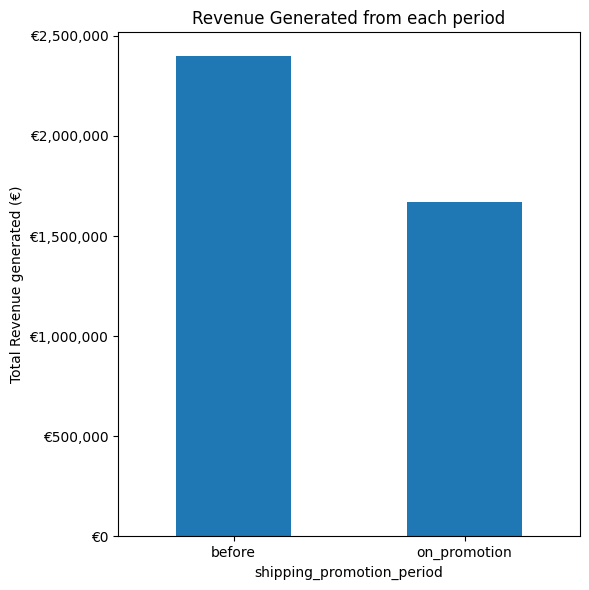

In [335]:
mr.drop_duplicates('order_id').groupby('shipping_promotion_period')['order_total'].sum().plot(
    kind="bar",
    figsize=(6, 6),
    ylabel="Total Revenue generated (€)",
    title="Revenue Generated from each period",
    legend=False, rot=0
)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.show()

* 69% of revenue from the previous period was generated only in those 3months of promotion period.

* profit margin across the different promotion period

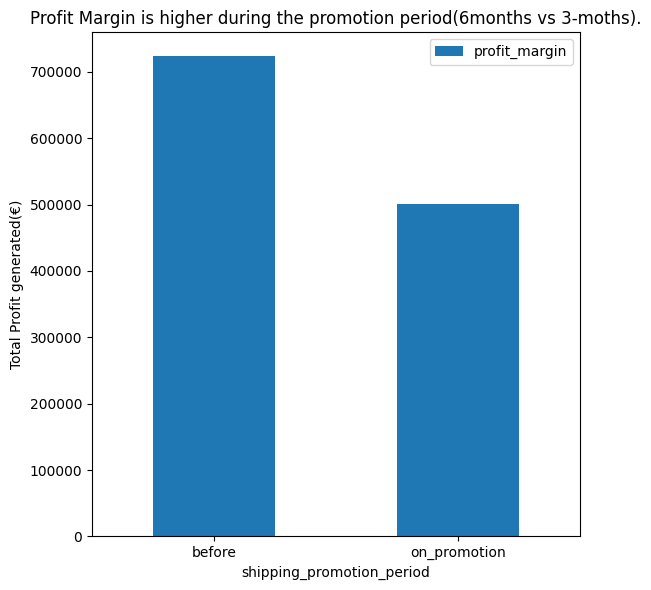

In [336]:
mr.groupby('shipping_promotion_period')['profit_margin'].sum().plot(
    kind="bar",
    figsize=(6,6),
    y="profit_margin",ylabel="Total Profit generated(€)",x = "shipping_promotion_period",title="Profit Margin is higher during the promotion period(6months vs 3-moths).",
    legend=True,rot=0
    )
plt.tight_layout()
plt.show()

* Profit margin across all the months

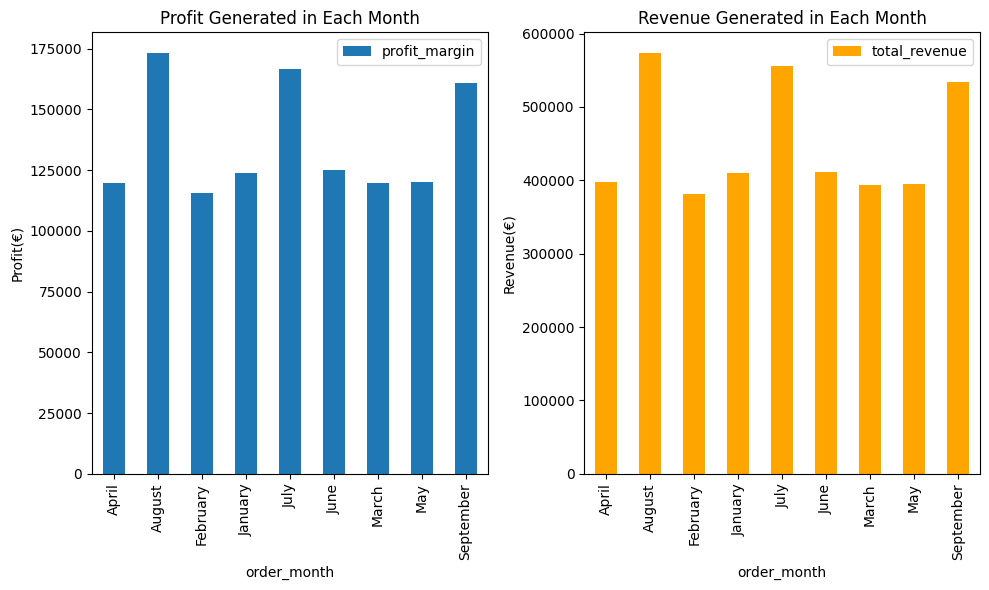

In [337]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

monthly_analysis['profit_margin'].plot(
    kind="bar",
    figsize=(10,6),ax=ax1,
    y='profit_margin',
    ylabel="Profit(€)",
    title="Profit Generated in Each Month",
    legend=True
    )

monthly_analysis['total_revenue'].plot( 
    kind="bar",
    figsize=(10,6),ax=ax2,
    y='total_revenue',
    ylabel="Revenue(€)",
    title="Revenue Generated in Each Month",
    legend=True,
    color="orange"
    )

plt.tight_layout()
plt.show()

* months of the promotion period generate higher profit and revenue

### * shipping cost distribution during promotion period

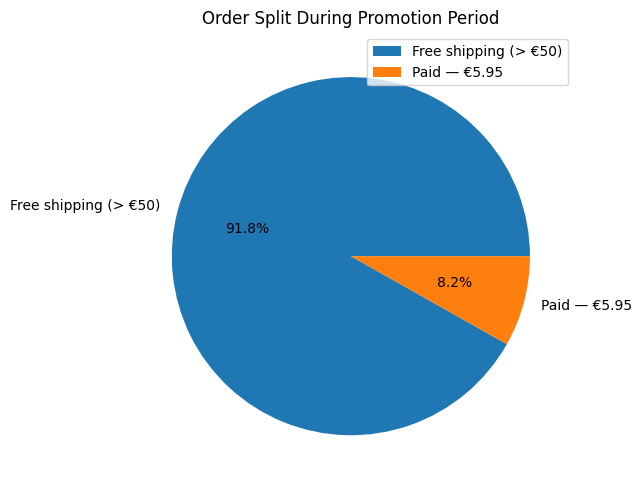

In [338]:
(on_promotion.drop_duplicates('order_id')
             .groupby('shipping_cost')
             .size()
             .rename({0.0: 'Free shipping (> €50)', 5.95: 'Paid — €5.95'})
             .plot(kind='pie', figsize=(6, 5),
                   autopct='%1.1f%%',
                   title='Order Split During Promotion Period',
                   legend=True))
plt.tight_layout()
plt.show()


* After promotion only 8.2% customers spend less than 50 euros.

* Promotion breakdown across product cost revenue, and net profit 

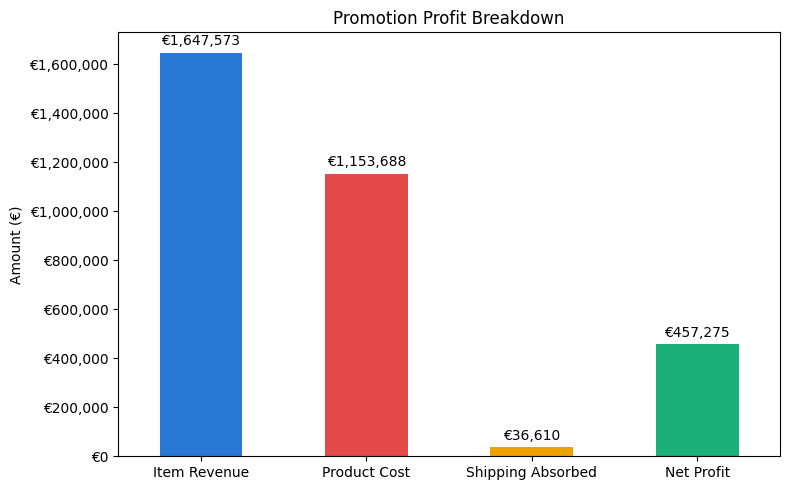

In [339]:
breakdown = pd.Series({
    'Item Revenue':       total_item_revenue,
    'Product Cost':      total_product_cost,
    'Shipping Absorbed': covered_shipping_cost,
    'Net Profit':         net_promo_profit
})

colors = ['#2a78d6', '#e34948', '#eda100', '#1baf7a' if net_promo_profit >= 0 else '#e34948']
ax = breakdown.plot(kind='bar', figsize=(8, 5), color=colors,
                     title='Promotion Profit Breakdown',
                     ylabel='Amount (€)', xlabel='', legend=False, rot=0)

ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# print the exact value on top of each bar
ax.bar_label(ax.containers[0], fmt=lambda v: f'€{v:,.0f}', padding=3)

plt.tight_layout()
plt.show()


* Item Revenue is much higher than the product cost.
* Net Profit is also much higher than the shipping absorbed by the compony.
* This all leads the Promotion brings undeniable profit on the company.

* Category distribution and profit generated

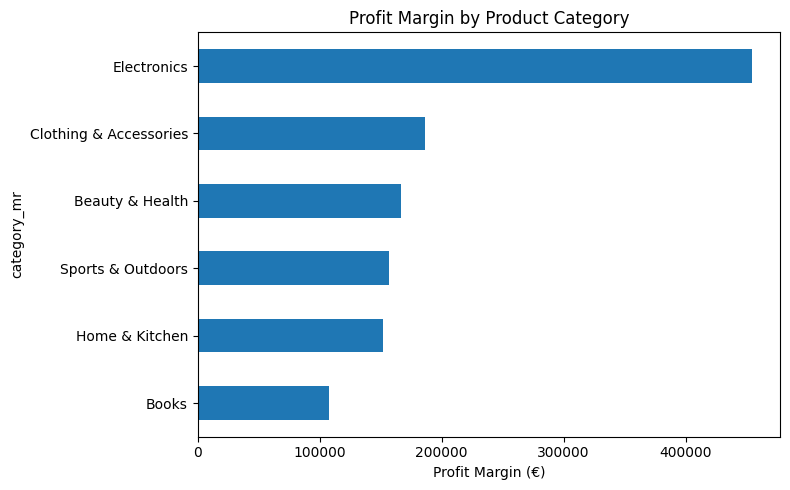

In [340]:
(mr.groupby('category_mr')['profit_margin']
   .sum()
   .sort_values()
   .plot(kind='barh', figsize=(8, 5),
         title='Profit Margin by Product Category',
         xlabel='Profit Margin (€)'))

plt.tight_layout()
plt.show()


* people spending across the two different promotion periods

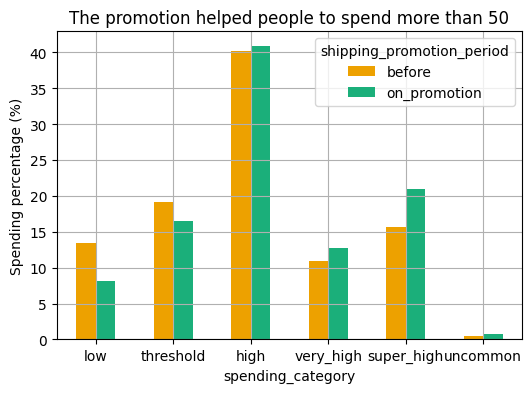

In [341]:
colors = ['#eda100', '#1baf7a']
spending_pcg.plot(
    kind='bar',legend=True,figsize=(6,4),color=colors,
    ylabel="Spending percentage (%)",
    xlabel="spending_category",
    title="The promotion helped people to spend more than 50",
    rot=0,grid=True
    )
plt.show()

* Region distribution across the promotion period.

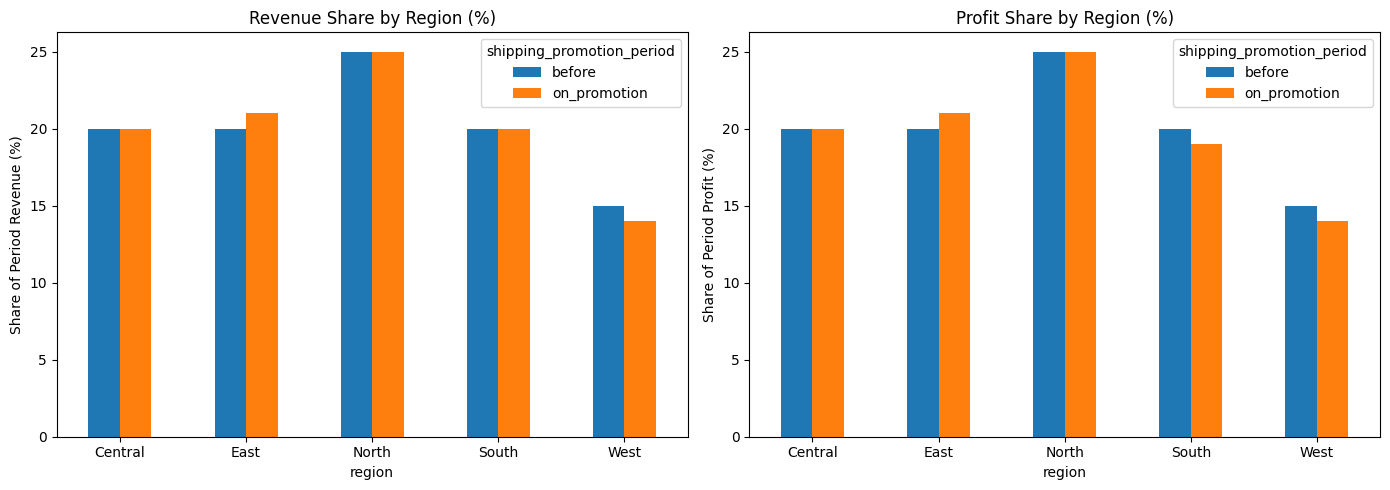

In [342]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

region_rev_pct.plot(kind='bar', ax=ax1, title='Revenue Share by Region (%)',
                    ylabel='Share of Period Revenue (%)', rot=0)

region_profit_pct.plot(kind='bar', ax=ax2, title='Profit Share by Region (%)',
                       ylabel='Share of Period Profit (%)', rot=0)

plt.tight_layout()
plt.show()

---

# conclusion
* Applying the promotion on the shipping cost brings undeniable positive change.
* Promotion period generated 69% of the revenue from previous period.
* 59.43% of orders of the previous period has made during the promotion period. 
* Spending behavior of the people has been changed because of the promotion.
* People tend to spent more than 50euros in each order, they made.
* Out of the total cost €1,153,687.99 of the products which has shipped free of charge, `€457,274.91` net profit is generated.
* Only in the 3-months a visible increase on revenue and profit has seen.
* During the promotion period around 60% of the amount of orders from the previous period has made.
* And the promotion helps to change the peoples behavior, by increasing their spending plan.

# Recommendations
* Keep free shipping above €50. the impact is positive and promising.
* introduce extra attention to the West region which has relatively smaller impact, to lift up.
